In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt

# Yolov5

In [2]:
# Root folder where all results are stored
base_path = r"C:\Users\Sarthak Aggarwal\Downloads\ISL_yolo"

# YOLOv5 result folders
folders = {
    "yolov5n": os.path.join(base_path, "yolov5n_results", "content", "yolov5", "runs", "train", "yolov5n_results", "results.csv"),
    "yolov5s": os.path.join(base_path, "yolov5s_results", "content", "yolov5", "runs", "train", "yolov5s_results", "results.csv"),
    "yolov5m": os.path.join(base_path, "yolov5m_results", "content", "yolov5", "runs", "train", "yolov5m_results", "results.csv"),
    "yolov5l": os.path.join(base_path, "yolov5l_results", "content", "yolov5", "runs", "train", "yolov5l_results", "results.csv"),
    "yolov5x": os.path.join(base_path, "yolov5x_results", "content", "yolov5", "runs", "train", "yolov5x_results", "results.csv"),
}

In [3]:
# Dictionary to store DataFrames
dataframes = {}

for model, path in folders.items():
    if os.path.exists(path):
        df = pd.read_csv(path)
        df["model"] = model  # Add column to identify model
        dataframes[model] = df
    else:
        print(f"⚠️ Missing file for {model}: {path}")

# Combine all into one big DataFrame
all_results = pd.concat(dataframes.values(), ignore_index=True)

# Show last epoch results only (final performance)
final_results = all_results.groupby("model").tail(1).reset_index(drop=True)

# Display the table
print("📊 Final YOLOv5 Results")
display(final_results)

📊 Final YOLOv5 Results


,epoch,train/box_loss,train/obj_loss,train/cls_loss,metrics/precision,metrics/recall,metrics/mAP_0.5,metrics/mAP_0.5:0.95,val/box_loss,val/obj_loss,val/cls_loss,x/lr0,x/lr1,x/lr2,model
0,9,0.039673,0.013861,0.068518,0.51115,0.35616,0.36185,0.17747,0.032820,0.010219,0.064720,0.00208,0.00208,0.00208,yolov5n
1,9,0.038542,0.013221,0.057815,0.56074,0.51439,0.49753,0.25248,0.035036,0.009869,0.051516,0.00208,0.00208,0.00208,yolov5s
2,9,0.037811,0.012654,0.040905,0.73180,0.71282,0.78909,0.39610,0.034970,0.009659,0.033509,0.00208,0.00208,0.00208,yolov5m
3,9,0.038038,0.012299,0.034598,0.85897,0.76415,0.84108,0.44704,0.033661,0.009512,0.029387,0.00208,0.00208,0.00208,yolov5l
4,9,0.037027,0.012065,0.028669,0.86434,0.87367,0.91012,0.47890,0.034142,0.009506,0.021470,0.00208,0.00208,0.00208,yolov5x


In [4]:
print(final_results.columns.tolist())

['               epoch', '      train/box_loss', '      train/obj_loss', '      train/cls_loss', '   metrics/precision', '      metrics/recall', '     metrics/mAP_0.5', 'metrics/mAP_0.5:0.95', '        val/box_loss', '        val/obj_loss', '        val/cls_loss', '               x/lr0', '               x/lr1', '               x/lr2', 'model']


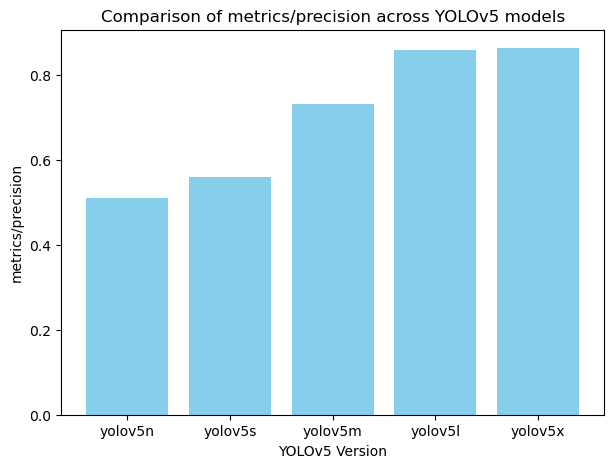

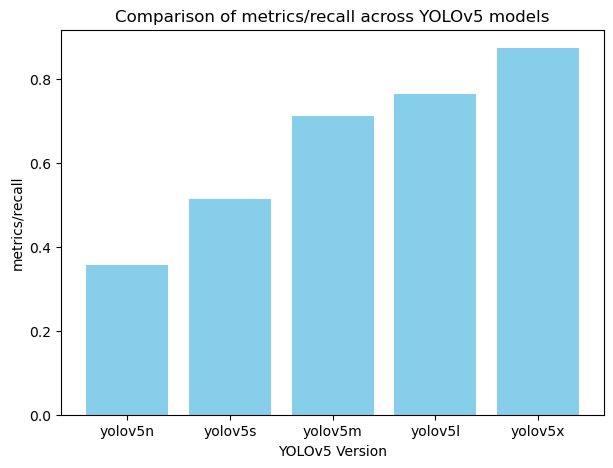

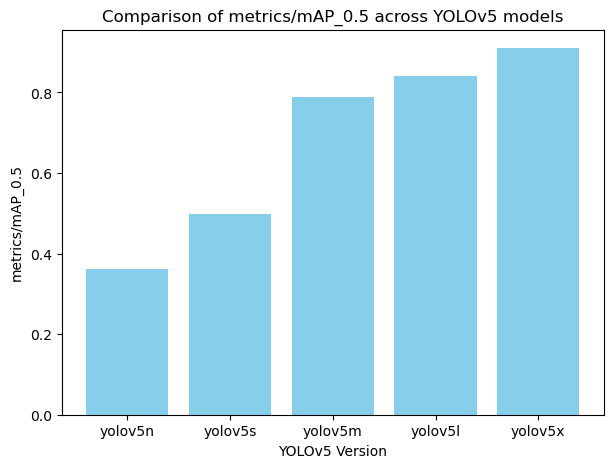

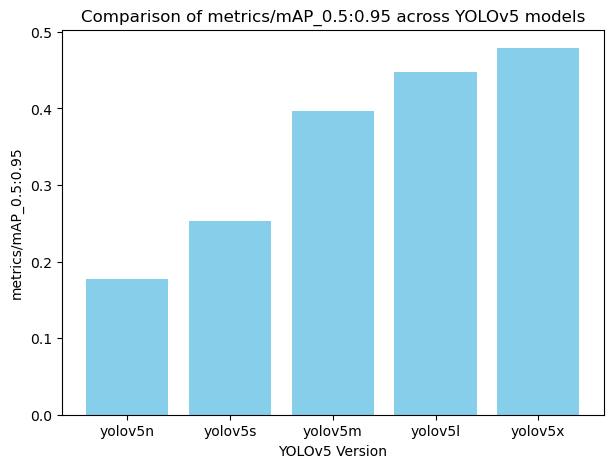

In [5]:
# Clean column names first
final_results.columns = final_results.columns.str.strip()

# Now your metrics will match correctly
metrics_to_compare = [
    "metrics/precision",
    "metrics/recall",
    "metrics/mAP_0.5",
    "metrics/mAP_0.5:0.95"
]

for metric in metrics_to_compare:
    if metric in final_results.columns:
        plt.figure(figsize=(7,5))
        plt.bar(final_results["model"], final_results[metric], color="skyblue")
        plt.title(f"Comparison of {metric} across YOLOv5 models")
        plt.ylabel(metric)
        plt.xlabel("YOLOv5 Version")
        plt.show()
    else:
        print(f"⚠️ Column not found: {metric}")

In [6]:
# Clean column names (important!)
for k in dataframes:
    dataframes[k].columns = dataframes[k].columns.str.strip()
final_results.columns = final_results.columns.str.strip()

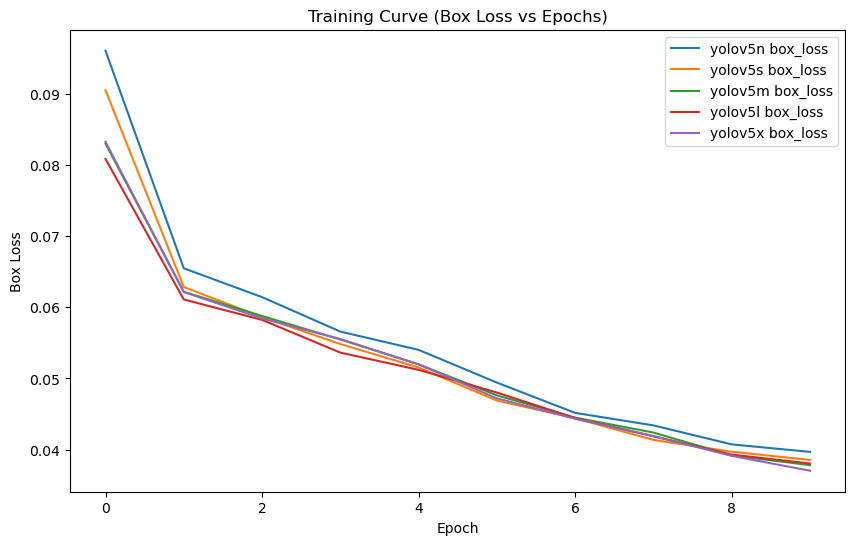

In [7]:
plt.figure(figsize=(10,6))
for model, df in dataframes.items():
    if "epoch" in df.columns:
        plt.plot(df["epoch"], df["train/box_loss"], label=f"{model} box_loss")
plt.title("Training Curve (Box Loss vs Epochs)")
plt.xlabel("Epoch")
plt.ylabel("Box Loss")
plt.legend()
plt.show()

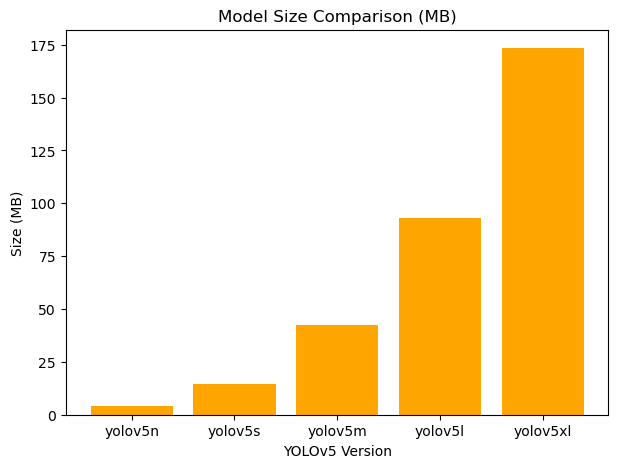

In [8]:
weights_path = {
    "yolov5n": os.path.join(base_path, "yolov5n_results", "content", "yolov5", "runs", "train", "yolov5n_results", "weights", "best.pt"),
    "yolov5s": os.path.join(base_path, "yolov5s_results", "content", "yolov5", "runs", "train", "yolov5s_results", "weights", "best.pt"),
    "yolov5m": os.path.join(base_path, "yolov5m_results", "content", "yolov5", "runs", "train", "yolov5m_results", "weights", "best.pt"),
    "yolov5l": os.path.join(base_path, "yolov5l_results", "content", "yolov5", "runs", "train", "yolov5l_results", "weights", "best.pt"),
    "yolov5xl": os.path.join(base_path, "yolov5x_results", "content", "yolov5", "runs", "train", "yolov5x_results", "weights", "best.pt"),
}

sizes = {model: os.path.getsize(path)/1e6 for model, path in weights_path.items() if os.path.exists(path)}

plt.figure(figsize=(7,5))
plt.bar(sizes.keys(), sizes.values(), color="orange")
plt.title("Model Size Comparison (MB)")
plt.ylabel("Size (MB)")
plt.xlabel("YOLOv5 Version")
plt.show()

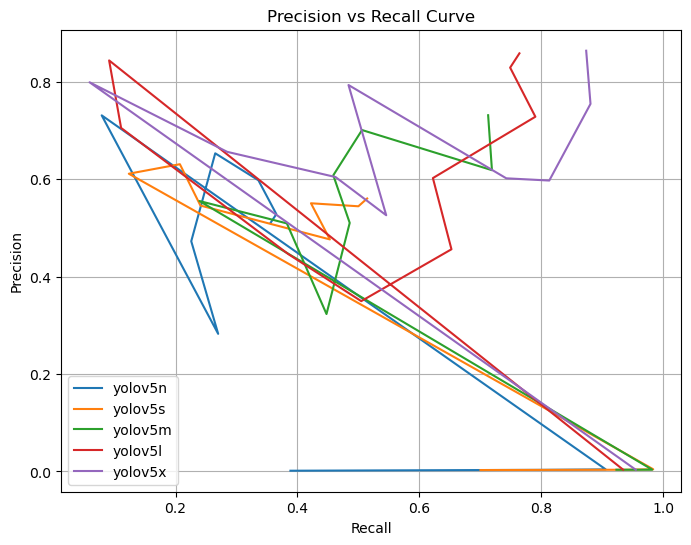

In [9]:
plt.figure(figsize=(8,6))
for model, df in dataframes.items():
    if "metrics/recall" in df.columns and "metrics/precision" in df.columns:
        plt.plot(df["metrics/recall"], df["metrics/precision"], label=model)

plt.title("Precision vs Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.grid(True)
plt.show()

# yolov8

In [10]:
# YOLOv8 result CSV paths (adjust if your folder structure is different)
folders_v8 = {
    "yolov8n": os.path.join(base_path, "yolov8n_results", "content", "runs", "detect", "train6", "results.csv"),
    "yolov8s": os.path.join(base_path, "yolov8s_results", "content", "runs", "detect", "train2", "results.csv"),
    "yolov8m": os.path.join(base_path, "yolov8m_results", "content", "runs", "detect", "train3", "results.csv"),
    "yolov8l": os.path.join(base_path, "yolov8l_results", "content", "runs", "detect", "train4", "results.csv"),
    "yolov8x": os.path.join(base_path, "yolov8x_results", "content", "datasets", "runs", "detect", "train2", "results.csv"),
}

dataframes_v8 = {}

for model, path in folders_v8.items():
    if os.path.exists(path):
        df = pd.read_csv(path)
        df.columns = df.columns.str.strip()
        df["model"] = model
        dataframes_v8[model] = df
    else:
        print(f"⚠️ Missing file for {model}: {path}")

# Combine and get final results (last epoch)
all_results_v8 = pd.concat(dataframes_v8.values(), ignore_index=True)
final_results_v8 = all_results_v8.groupby("model").tail(1).reset_index(drop=True)

print("📊 Final YOLOv8 Results")
display(final_results_v8)


📊 Final YOLOv8 Results


,epoch,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2,model
0,10,1.2830,1.86610,1.3628,0.91901,0.93296,0.96378,0.58791,1.4296,0.81614,1.4198,0.000033,0.000033,0.000033,yolov8n
1,10,1.2348,0.70544,1.2202,0.93217,0.96273,0.97122,0.58447,1.4314,0.62670,1.3273,0.000033,0.000033,0.000033,yolov8s
2,10,1.1953,0.65139,1.5501,0.91157,0.95909,0.97341,0.59008,1.4631,0.63151,1.7390,0.000033,0.000033,0.000033,yolov8m
3,10,1.2236,0.66849,1.6448,0.92686,0.95476,0.97412,0.59871,1.4087,0.63404,1.7964,0.000033,0.000033,0.000033,yolov8l
4,10,1.2383,0.63796,1.4582,0.90345,0.97512,0.97267,0.59660,1.4226,0.60318,1.5800,0.000033,0.000033,0.000033,yolov8x


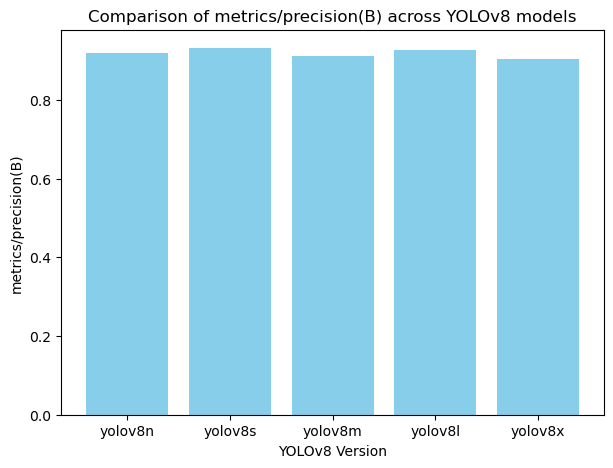

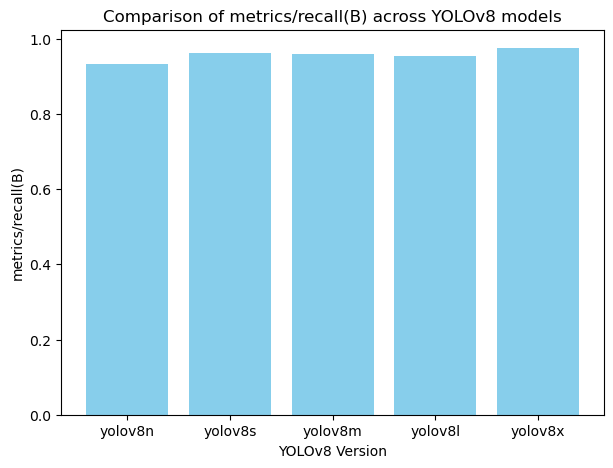

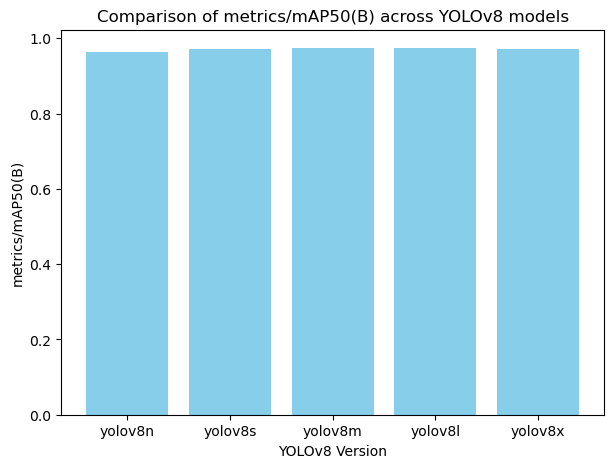

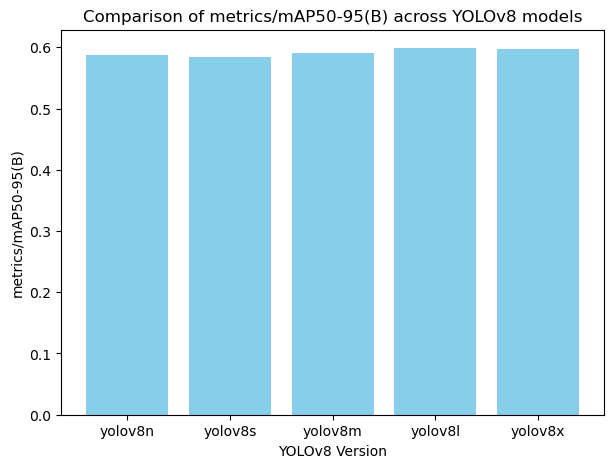

In [11]:
# Clean column names
final_results_v8.columns = final_results_v8.columns.str.strip()

# Metrics to compare
metrics_to_compare = [
    "metrics/precision(B)",
    "metrics/recall(B)",
    "metrics/mAP50(B)",
    "metrics/mAP50-95(B)"
]

# Plot each metric for YOLOv8 models
for metric in metrics_to_compare:
    if metric in final_results_v8.columns:
        plt.figure(figsize=(7,5))
        plt.bar(final_results_v8["model"], final_results_v8[metric], color="skyblue")
        plt.title(f"Comparison of {metric} across YOLOv8 models")
        plt.ylabel(metric)
        plt.xlabel("YOLOv8 Version")
        plt.show()
    else:
        print(f"⚠️ Column not found: {metric}")


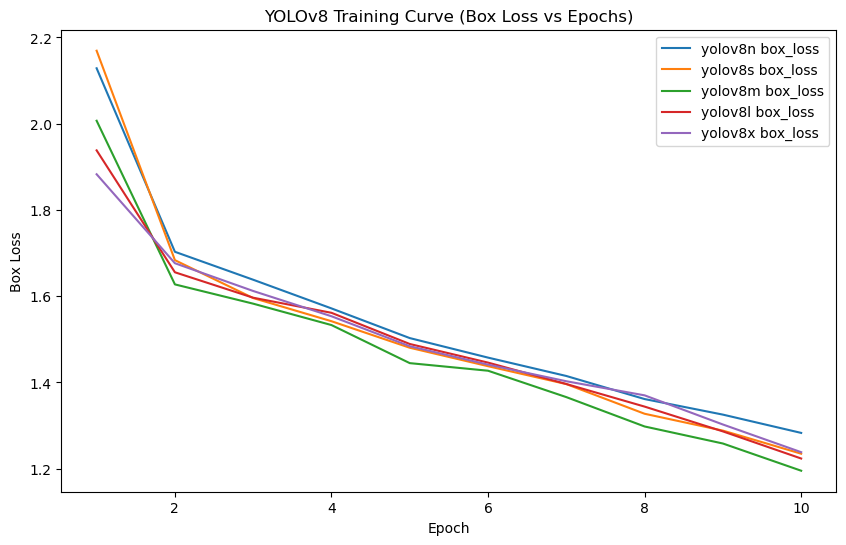

In [12]:
plt.figure(figsize=(10,6))
for model, df in dataframes_v8.items():
    if "epoch" in df.columns and "train/box_loss" in df.columns:
        plt.plot(df["epoch"], df["train/box_loss"], label=f"{model} box_loss")

plt.title("YOLOv8 Training Curve (Box Loss vs Epochs)")
plt.xlabel("Epoch")
plt.ylabel("Box Loss")
plt.legend()
plt.show()

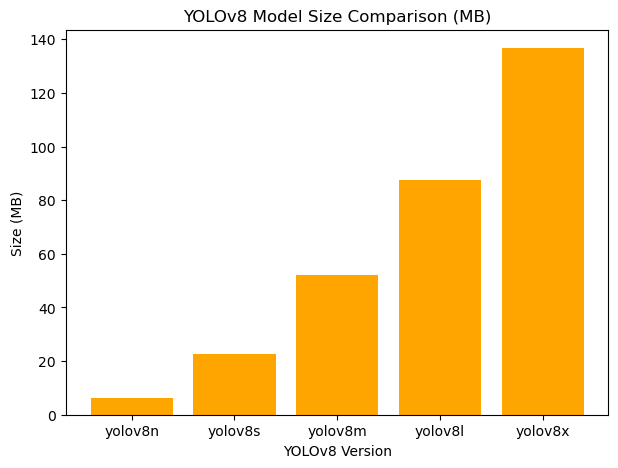

In [13]:
weights_path_v8 = {
    "yolov8n": os.path.join(base_path, "yolov8n_results", "content", "runs", "detect", "train6", "weights", "best.pt"),
    "yolov8s": os.path.join(base_path, "yolov8s_results", "content", "runs", "detect", "train2", "weights", "best.pt"),
    "yolov8m": os.path.join(base_path, "yolov8m_results", "content", "runs", "detect", "train3", "weights", "best.pt"),
    "yolov8l": os.path.join(base_path, "yolov8l_results", "content", "runs", "detect", "train4", "weights", "best.pt"),
    "yolov8x": os.path.join(base_path, "yolov8x_results", "content", "datasets", "runs", "detect", "train2","weights", "best.pt"),
}

sizes_v8 = {model: os.path.getsize(path)/1e6 for model, path in weights_path_v8.items() if os.path.exists(path)}

plt.figure(figsize=(7,5))
plt.bar(sizes_v8.keys(), sizes_v8.values(), color="orange")
plt.title("YOLOv8 Model Size Comparison (MB)")
plt.ylabel("Size (MB)")
plt.xlabel("YOLOv8 Version")
plt.show()


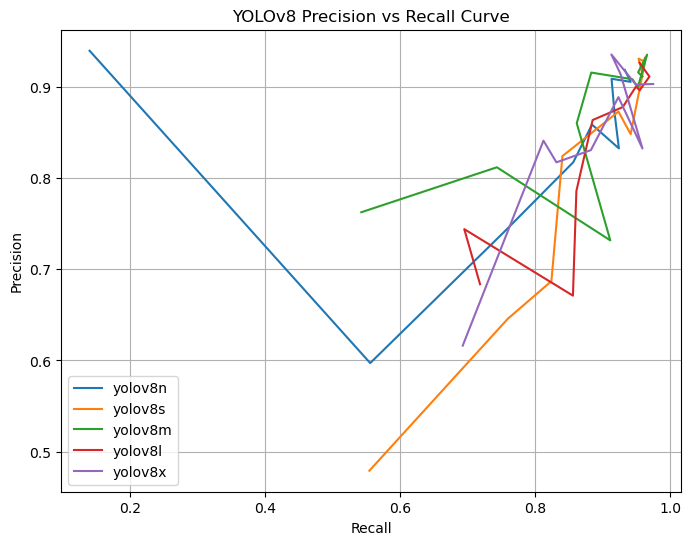

In [14]:
plt.figure(figsize=(8,6))
for model, df in dataframes_v8.items():
    if "metrics/recall(B)" in df.columns and "metrics/precision(B)" in df.columns:
        plt.plot(df["metrics/recall(B)"], df["metrics/precision(B)"], label=model)

plt.title("YOLOv8 Precision vs Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.grid(True)
plt.show()

In [15]:
# Just to confirm final dataset cleanliness
for k in dataframes_v8:
    dataframes_v8[k].columns = dataframes_v8[k].columns.str.strip()
final_results_v8.columns = final_results_v8.columns.str.strip()

print("✅ YOLOv8 DataFrames cleaned and ready.")
display(final_results_v8)

✅ YOLOv8 DataFrames cleaned and ready.


,epoch,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2,model
0,10,1.2830,1.86610,1.3628,0.91901,0.93296,0.96378,0.58791,1.4296,0.81614,1.4198,0.000033,0.000033,0.000033,yolov8n
1,10,1.2348,0.70544,1.2202,0.93217,0.96273,0.97122,0.58447,1.4314,0.62670,1.3273,0.000033,0.000033,0.000033,yolov8s
2,10,1.1953,0.65139,1.5501,0.91157,0.95909,0.97341,0.59008,1.4631,0.63151,1.7390,0.000033,0.000033,0.000033,yolov8m
3,10,1.2236,0.66849,1.6448,0.92686,0.95476,0.97412,0.59871,1.4087,0.63404,1.7964,0.000033,0.000033,0.000033,yolov8l
4,10,1.2383,0.63796,1.4582,0.90345,0.97512,0.97267,0.59660,1.4226,0.60318,1.5800,0.000033,0.000033,0.000033,yolov8x


# Yolov10

In [16]:
# YOLOv10 result CSV paths (adjust if your folder structure is different)
folders_v10 = {
    "yolov10n": os.path.join(base_path, "yolov10n_results", "content", "runs", "detect", "yolov10n_isl_custom3", "results.csv"),
    "yolov10s": os.path.join(base_path, "yolov10s_results", "content", "runs", "detect", "yolov10s_isl_custom2", "results.csv"),
    "yolov10m": os.path.join(base_path, "yolov10m_results", "content", "runs", "detect", "yolov10m_isl_custom", "results.csv"),
    "yolov10l": os.path.join(base_path, "yolov10l_results", "content", "runs", "detect", "yolov10l_isl_custom", "results.csv"),
    "yolov10x": os.path.join(base_path, "yolov10x_results", "content", "runs", "detect", "yolov10x3_isl_custom", "results.csv"),
}

dataframes_v10 = {}

for model, path in folders_v10.items():
    if os.path.exists(path):
        df = pd.read_csv(path)
        df.columns = df.columns.str.strip()
        df["model"] = model
        dataframes_v10[model] = df
    else:
        print(f"⚠️ Missing file for {model}: {path}")

# Combine and get final results (last epoch)
all_results_v10 = pd.concat(dataframes_v10.values(), ignore_index=True)
final_results_v10 = all_results_v10.groupby("model").tail(1).reset_index(drop=True)

print("📊 Final YOLOv10 Results")
display(final_results_v10)

📊 Final YOLOv10 Results


,epoch,train/box_om,train/cls_om,train/dfl_om,train/box_oo,train/cls_oo,train/dfl_oo,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),...,val/box_om,val/cls_om,val/dfl_om,val/box_oo,val/cls_oo,val/dfl_oo,lr/pg0,lr/pg1,lr/pg2,model
0,10,1.5041,2.98730,1.4023,1.3405,9.4487,1.2809,0.68957,0.54987,0.70612,...,1.5064,2.20300,1.4502,1.3872,6.45940,1.3508,0.000063,0.000063,0.000063,yolov10n
1,10,1.4261,0.99344,1.4884,1.4546,1.8228,1.5006,0.66560,0.78554,0.82865,...,1.4551,0.92615,1.6006,1.3924,1.57480,1.5407,0.000063,0.000063,0.000063,yolov10s
2,10,1.4345,0.99170,1.7718,1.4846,1.5922,1.6633,0.72124,0.79933,0.84428,...,1.5679,0.94543,1.9069,1.6097,1.32360,1.7991,0.000063,0.000063,0.000063,yolov10m
3,10,1.3951,0.91893,1.6977,1.3898,1.4031,1.7120,0.80888,0.84186,0.90276,...,1.4601,0.83269,1.8041,1.4604,1.20170,1.8400,0.000063,0.000063,0.000063,yolov10l
4,10,1.4753,0.83472,1.5652,1.4871,1.0304,1.5976,0.79924,0.88744,0.89157,...,1.5000,0.77831,1.6543,1.5207,0.89369,1.6851,0.000063,0.000063,0.000063,yolov10x


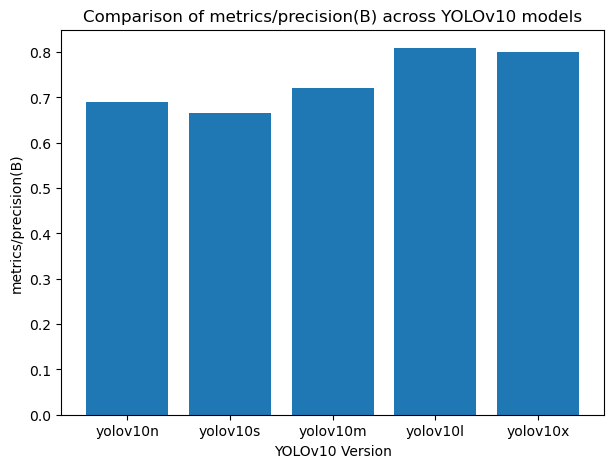

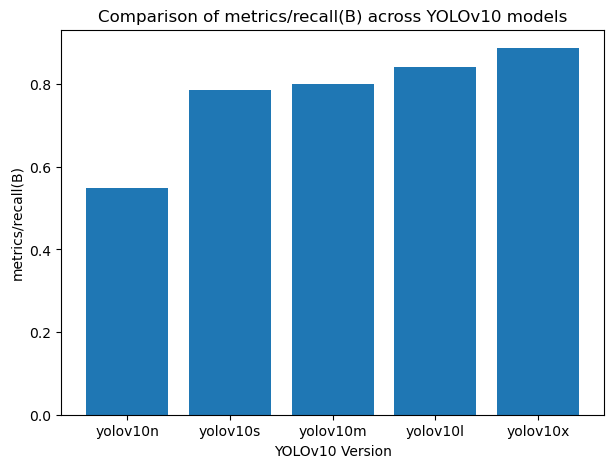

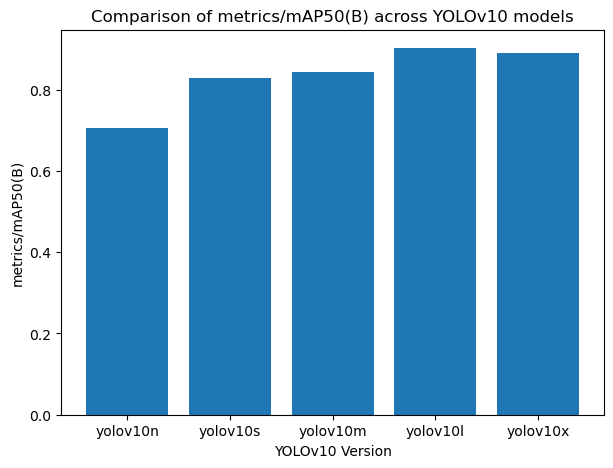

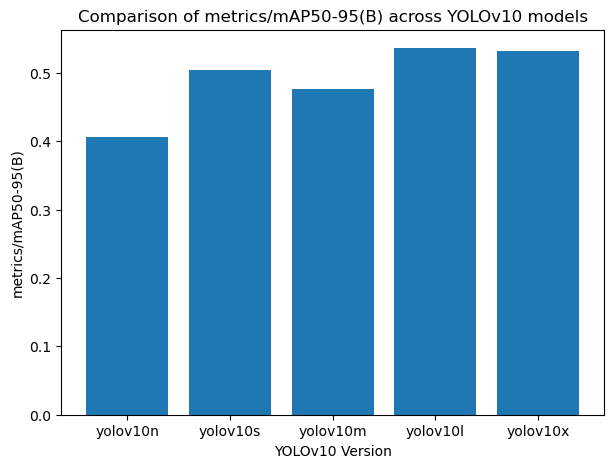

In [17]:
# Clean column names
final_results_v10.columns = final_results_v10.columns.str.strip()

# Metrics to compare
metrics_to_compare = [
    "metrics/precision(B)",
    "metrics/recall(B)",
    "metrics/mAP50(B)",
    "metrics/mAP50-95(B)"
]

# Plot each metric for YOLOv10 models
for metric in metrics_to_compare:
    if metric in final_results_v10.columns:
        plt.figure(figsize=(7,5))
        plt.bar(final_results_v10["model"], final_results_v10[metric])
        plt.title(f"Comparison of {metric} across YOLOv10 models")
        plt.ylabel(metric)
        plt.xlabel("YOLOv10 Version")
        plt.show()
    else:
        print(f"⚠️ Column not found: {metric}")

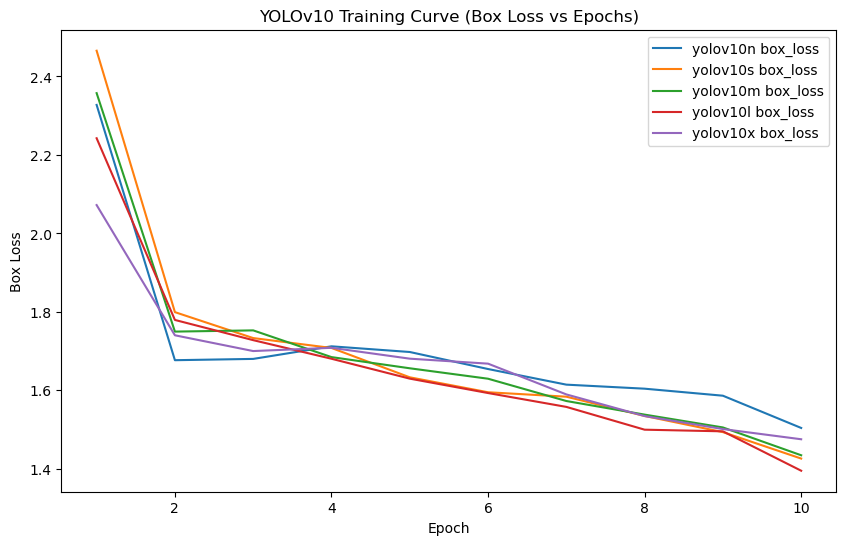

In [18]:
plt.figure(figsize=(10,6))

for model, df in dataframes_v10.items():
    if "epoch" in df.columns and "train/box_om" in df.columns:
        plt.plot(df["epoch"], df["train/box_om"], label=f"{model} box_loss")

plt.title("YOLOv10 Training Curve (Box Loss vs Epochs)")
plt.xlabel("Epoch")
plt.ylabel("Box Loss")
plt.legend()
plt.show()

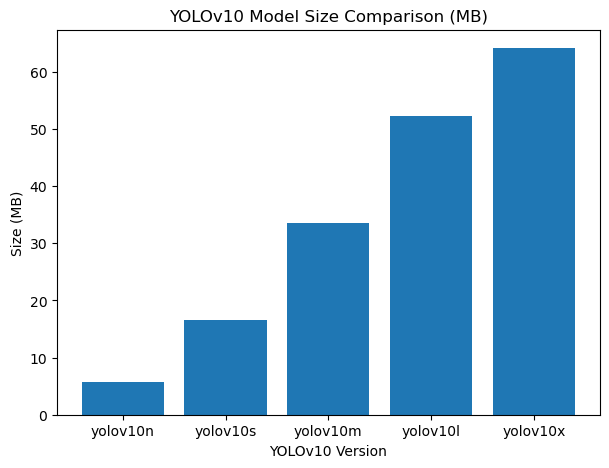

In [19]:
# YOLOv10 weights paths
weights_path_v10 = {
    "yolov10n": os.path.join(base_path, "yolov10n_results", "content", "runs", "detect", "yolov10n_isl_custom3", "weights", "best.pt"),
    "yolov10s": os.path.join(base_path, "yolov10s_results", "content", "runs", "detect", "yolov10s_isl_custom2", "weights", "best.pt"),
    "yolov10m": os.path.join(base_path, "yolov10m_results", "content", "runs", "detect", "yolov10m_isl_custom", "weights", "best.pt"),
    "yolov10l": os.path.join(base_path, "yolov10l_results", "content", "runs", "detect", "yolov10l_isl_custom", "weights", "best.pt"),
    "yolov10x": os.path.join(base_path, "yolov10x_results", "content", "runs", "detect", "yolov10x3_isl_custom", "weights", "best.pt"),
}

# Calculate model sizes (in MB)
sizes_v10 = {
    model: os.path.getsize(path) / 1e6
    for model, path in weights_path_v10.items()
    if os.path.exists(path)
}

plt.figure(figsize=(7,5))
plt.bar(sizes_v10.keys(), sizes_v10.values())
plt.title("YOLOv10 Model Size Comparison (MB)")
plt.ylabel("Size (MB)")
plt.xlabel("YOLOv10 Version")
plt.show()

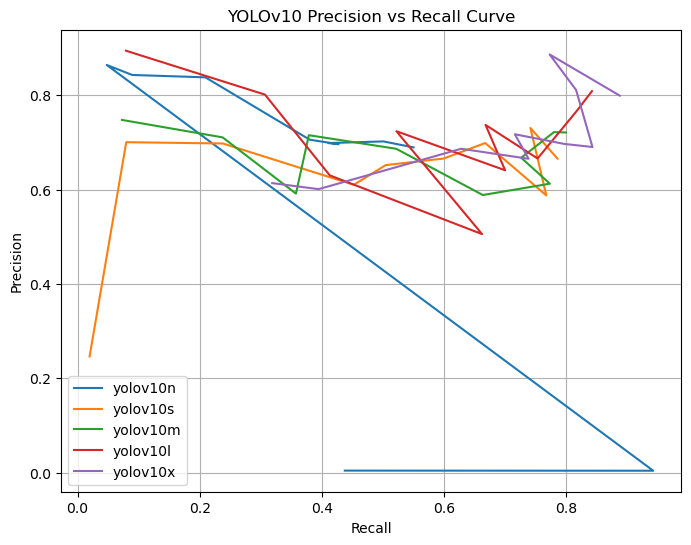

In [20]:
plt.figure(figsize=(8,6))

for model, df in dataframes_v10.items():
    if "metrics/recall(B)" in df.columns and "metrics/precision(B)" in df.columns:
        plt.plot(df["metrics/recall(B)"], df["metrics/precision(B)"], label=model)

plt.title("YOLOv10 Precision vs Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.grid(True)
plt.show()

In [21]:
# Clean column names in each YOLOv10 dataframe
for k in dataframes_v10:
    dataframes_v10[k].columns = dataframes_v10[k].columns.str.strip()

# Clean final results too
final_results_v10.columns = final_results_v10.columns.str.strip()

print("✅ YOLOv10 DataFrames cleaned and ready.")
display(final_results_v10)

✅ YOLOv10 DataFrames cleaned and ready.


,epoch,train/box_om,train/cls_om,train/dfl_om,train/box_oo,train/cls_oo,train/dfl_oo,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),...,val/box_om,val/cls_om,val/dfl_om,val/box_oo,val/cls_oo,val/dfl_oo,lr/pg0,lr/pg1,lr/pg2,model
0,10,1.5041,2.98730,1.4023,1.3405,9.4487,1.2809,0.68957,0.54987,0.70612,...,1.5064,2.20300,1.4502,1.3872,6.45940,1.3508,0.000063,0.000063,0.000063,yolov10n
1,10,1.4261,0.99344,1.4884,1.4546,1.8228,1.5006,0.66560,0.78554,0.82865,...,1.4551,0.92615,1.6006,1.3924,1.57480,1.5407,0.000063,0.000063,0.000063,yolov10s
2,10,1.4345,0.99170,1.7718,1.4846,1.5922,1.6633,0.72124,0.79933,0.84428,...,1.5679,0.94543,1.9069,1.6097,1.32360,1.7991,0.000063,0.000063,0.000063,yolov10m
3,10,1.3951,0.91893,1.6977,1.3898,1.4031,1.7120,0.80888,0.84186,0.90276,...,1.4601,0.83269,1.8041,1.4604,1.20170,1.8400,0.000063,0.000063,0.000063,yolov10l
4,10,1.4753,0.83472,1.5652,1.4871,1.0304,1.5976,0.79924,0.88744,0.89157,...,1.5000,0.77831,1.6543,1.5207,0.89369,1.6851,0.000063,0.000063,0.000063,yolov10x


# YOLOv5 vs YOLOv8 vs YOLOv10

In [22]:
# YOLOv5 results
folders_v5 = {
    "yolov5n": os.path.join(base_path, "yolov5n_results", "content", "yolov5", "runs", "train", "yolov5n_results", "results.csv"),
    "yolov5s": os.path.join(base_path, "yolov5s_results", "content", "yolov5", "runs", "train", "yolov5s_results", "results.csv"),
    "yolov5m": os.path.join(base_path, "yolov5m_results", "content", "yolov5", "runs", "train", "yolov5m_results", "results.csv"),
    "yolov5l": os.path.join(base_path, "yolov5l_results", "content", "yolov5", "runs", "train", "yolov5l_results", "results.csv"),
    "yolov5x": os.path.join(base_path, "yolov5x_results", "content", "yolov5", "runs", "train", "yolov5x_results", "results.csv"),
}

# YOLOv8 results
folders_v8 = {
    "yolov8n": os.path.join(base_path, "yolov8n_results", "content", "runs", "detect", "train6", "results.csv"),
    "yolov8s": os.path.join(base_path, "yolov8s_results", "content", "runs", "detect", "train2", "results.csv"),
    "yolov8m": os.path.join(base_path, "yolov8m_results", "content", "runs", "detect", "train3", "results.csv"),
    "yolov8l": os.path.join(base_path, "yolov8l_results", "content", "runs", "detect", "train4", "results.csv"),
    "yolov8x": os.path.join(base_path, "yolov8x_results", "content", "datasets", "runs", "detect", "train2", "results.csv"),
}

# YOLOv10 results
folders_v10 = {
    "yolov10n": os.path.join(base_path, "yolov10n_results", "content", "runs", "detect", "yolov10n_isl_custom3", "results.csv"),
    "yolov10s": os.path.join(base_path, "yolov10s_results", "content", "runs", "detect", "yolov10s_isl_custom2", "results.csv"),
    "yolov10m": os.path.join(base_path, "yolov10m_results", "content", "runs", "detect", "yolov10m_isl_custom", "results.csv"),
    "yolov10l": os.path.join(base_path, "yolov10l_results", "content", "runs", "detect", "yolov10l_isl_custom", "results.csv"),
    "yolov10x": os.path.join(base_path, "yolov10x_results", "content", "runs", "detect", "yolov10x3_isl_custom", "results.csv"),
}

# Function to load results
def load_results(folders, version="v5"):
    dfs = {}
    for model, path in folders.items():
        if os.path.exists(path):
            df = pd.read_csv(path)
            df.columns = df.columns.str.strip()

            # Standardize column names for YOLOv8 & YOLOv10
            if version in ["v8", "v10"]:
                df = df.rename(columns={
                    "metrics/precision(B)": "metrics/precision",
                    "metrics/recall(B)": "metrics/recall",
                    "metrics/mAP50(B)": "metrics/mAP_0.5",
                    "metrics/mAP50-95(B)": "metrics/mAP_0.5:0.95"
                })

            df["model"] = model
            dfs[model] = df
        else:
            print(f"⚠️ Missing file for {model}: {path}")
    return dfs

# Load all YOLO versions
dataframes_v5 = load_results(folders_v5, version="v5")
dataframes_v8 = load_results(folders_v8, version="v8")
dataframes_v10 = load_results(folders_v10, version="v10")

In [23]:
# Combine YOLOv5, YOLOv8, YOLOv10 separately
all_results_v5 = pd.concat(dataframes_v5.values(), ignore_index=True)
all_results_v8 = pd.concat(dataframes_v8.values(), ignore_index=True)
all_results_v10 = pd.concat(dataframes_v10.values(), ignore_index=True)

# Take last epoch (final model performance)
final_results_v5 = all_results_v5.groupby("model").tail(1).reset_index(drop=True)
final_results_v8 = all_results_v8.groupby("model").tail(1).reset_index(drop=True)
final_results_v10 = all_results_v10.groupby("model").tail(1).reset_index(drop=True)

print("📊 Final YOLOv5 Results")
display(final_results_v5)

print("📊 Final YOLOv8 Results")
display(final_results_v8)

print("📊 Final YOLOv10 Results")
display(final_results_v10)

📊 Final YOLOv5 Results


,epoch,train/box_loss,train/obj_loss,train/cls_loss,metrics/precision,metrics/recall,metrics/mAP_0.5,metrics/mAP_0.5:0.95,val/box_loss,val/obj_loss,val/cls_loss,x/lr0,x/lr1,x/lr2,model
0,9,0.039673,0.013861,0.068518,0.51115,0.35616,0.36185,0.17747,0.032820,0.010219,0.064720,0.00208,0.00208,0.00208,yolov5n
1,9,0.038542,0.013221,0.057815,0.56074,0.51439,0.49753,0.25248,0.035036,0.009869,0.051516,0.00208,0.00208,0.00208,yolov5s
2,9,0.037811,0.012654,0.040905,0.73180,0.71282,0.78909,0.39610,0.034970,0.009659,0.033509,0.00208,0.00208,0.00208,yolov5m
3,9,0.038038,0.012299,0.034598,0.85897,0.76415,0.84108,0.44704,0.033661,0.009512,0.029387,0.00208,0.00208,0.00208,yolov5l
4,9,0.037027,0.012065,0.028669,0.86434,0.87367,0.91012,0.47890,0.034142,0.009506,0.021470,0.00208,0.00208,0.00208,yolov5x


📊 Final YOLOv8 Results


,epoch,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision,metrics/recall,metrics/mAP_0.5,metrics/mAP_0.5:0.95,val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2,model
0,10,1.2830,1.86610,1.3628,0.91901,0.93296,0.96378,0.58791,1.4296,0.81614,1.4198,0.000033,0.000033,0.000033,yolov8n
1,10,1.2348,0.70544,1.2202,0.93217,0.96273,0.97122,0.58447,1.4314,0.62670,1.3273,0.000033,0.000033,0.000033,yolov8s
2,10,1.1953,0.65139,1.5501,0.91157,0.95909,0.97341,0.59008,1.4631,0.63151,1.7390,0.000033,0.000033,0.000033,yolov8m
3,10,1.2236,0.66849,1.6448,0.92686,0.95476,0.97412,0.59871,1.4087,0.63404,1.7964,0.000033,0.000033,0.000033,yolov8l
4,10,1.2383,0.63796,1.4582,0.90345,0.97512,0.97267,0.59660,1.4226,0.60318,1.5800,0.000033,0.000033,0.000033,yolov8x


📊 Final YOLOv10 Results


,epoch,train/box_om,train/cls_om,train/dfl_om,train/box_oo,train/cls_oo,train/dfl_oo,metrics/precision,metrics/recall,metrics/mAP_0.5,...,val/box_om,val/cls_om,val/dfl_om,val/box_oo,val/cls_oo,val/dfl_oo,lr/pg0,lr/pg1,lr/pg2,model
0,10,1.5041,2.98730,1.4023,1.3405,9.4487,1.2809,0.68957,0.54987,0.70612,...,1.5064,2.20300,1.4502,1.3872,6.45940,1.3508,0.000063,0.000063,0.000063,yolov10n
1,10,1.4261,0.99344,1.4884,1.4546,1.8228,1.5006,0.66560,0.78554,0.82865,...,1.4551,0.92615,1.6006,1.3924,1.57480,1.5407,0.000063,0.000063,0.000063,yolov10s
2,10,1.4345,0.99170,1.7718,1.4846,1.5922,1.6633,0.72124,0.79933,0.84428,...,1.5679,0.94543,1.9069,1.6097,1.32360,1.7991,0.000063,0.000063,0.000063,yolov10m
3,10,1.3951,0.91893,1.6977,1.3898,1.4031,1.7120,0.80888,0.84186,0.90276,...,1.4601,0.83269,1.8041,1.4604,1.20170,1.8400,0.000063,0.000063,0.000063,yolov10l
4,10,1.4753,0.83472,1.5652,1.4871,1.0304,1.5976,0.79924,0.88744,0.89157,...,1.5000,0.77831,1.6543,1.5207,0.89369,1.6851,0.000063,0.000063,0.000063,yolov10x


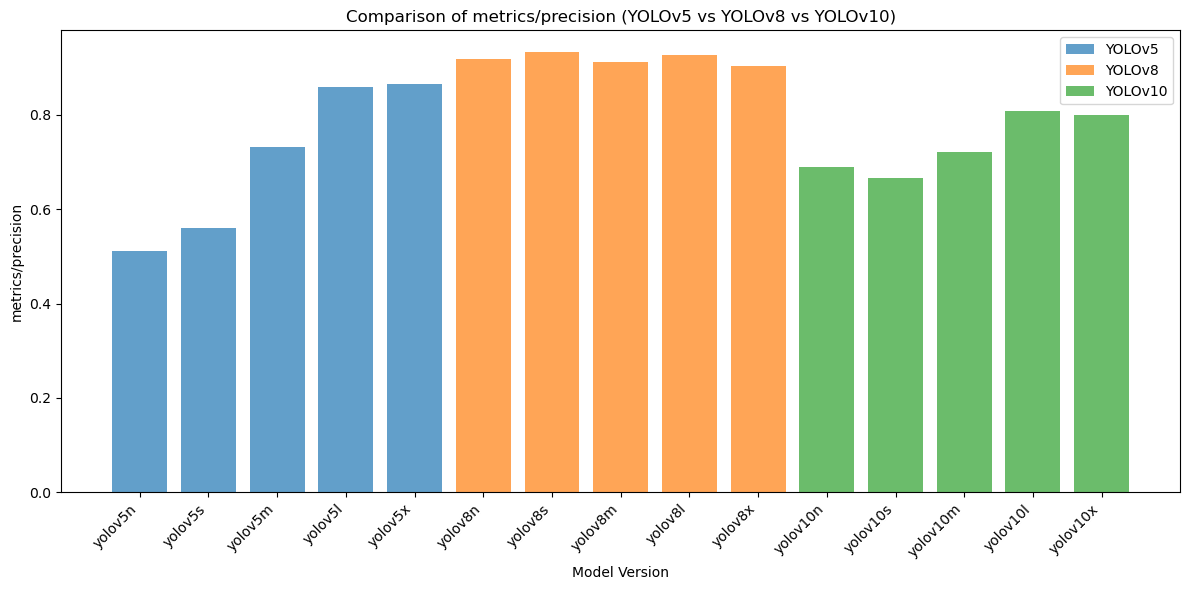

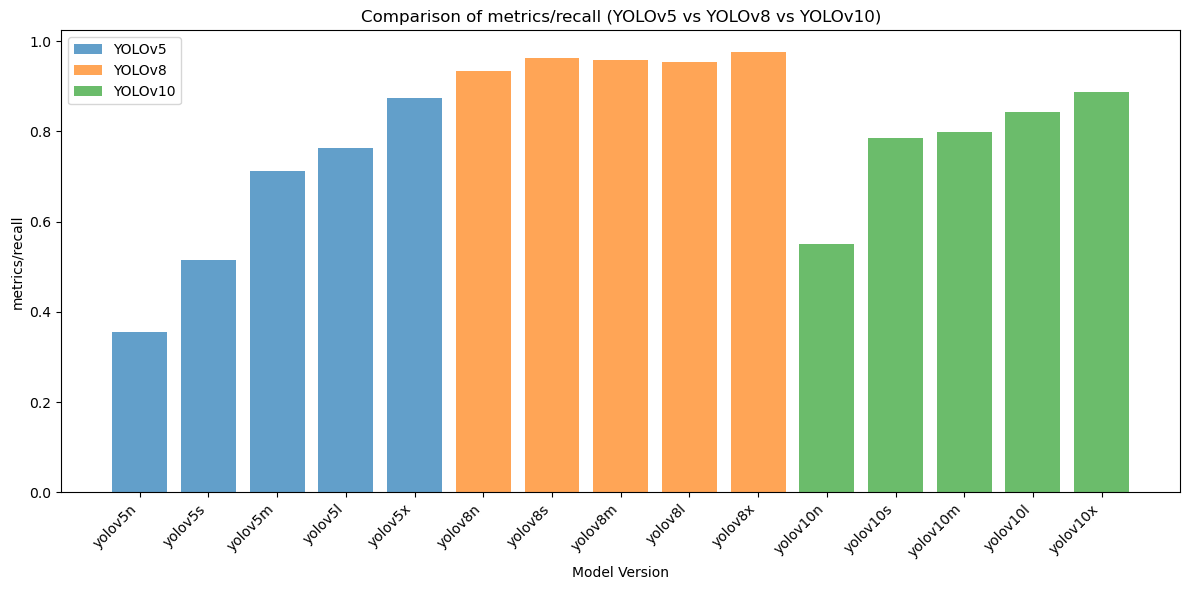

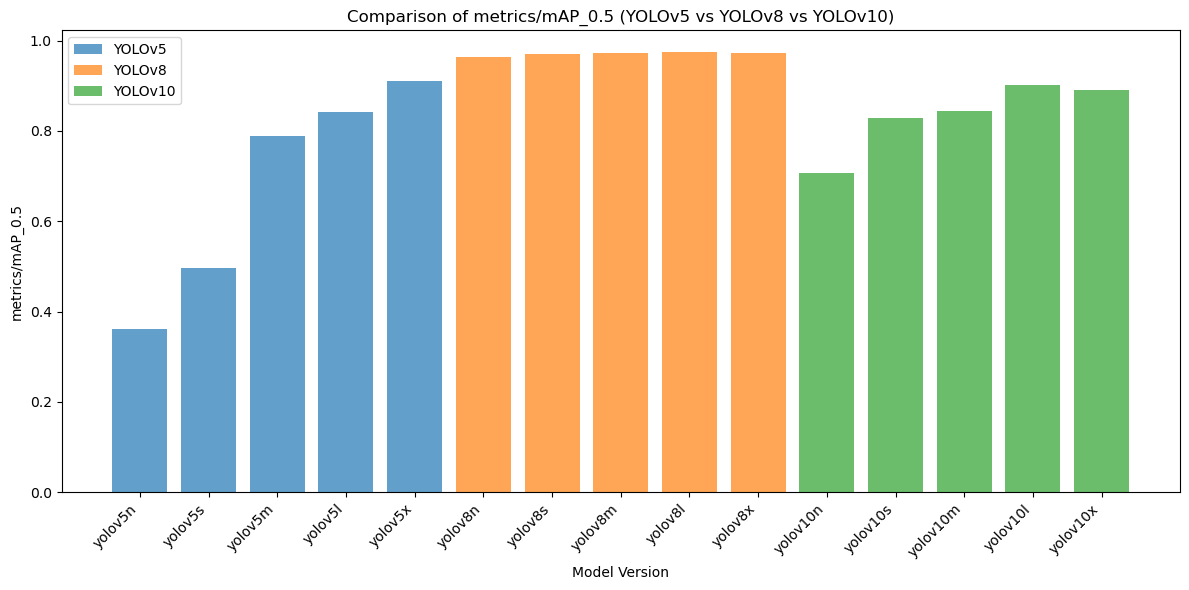

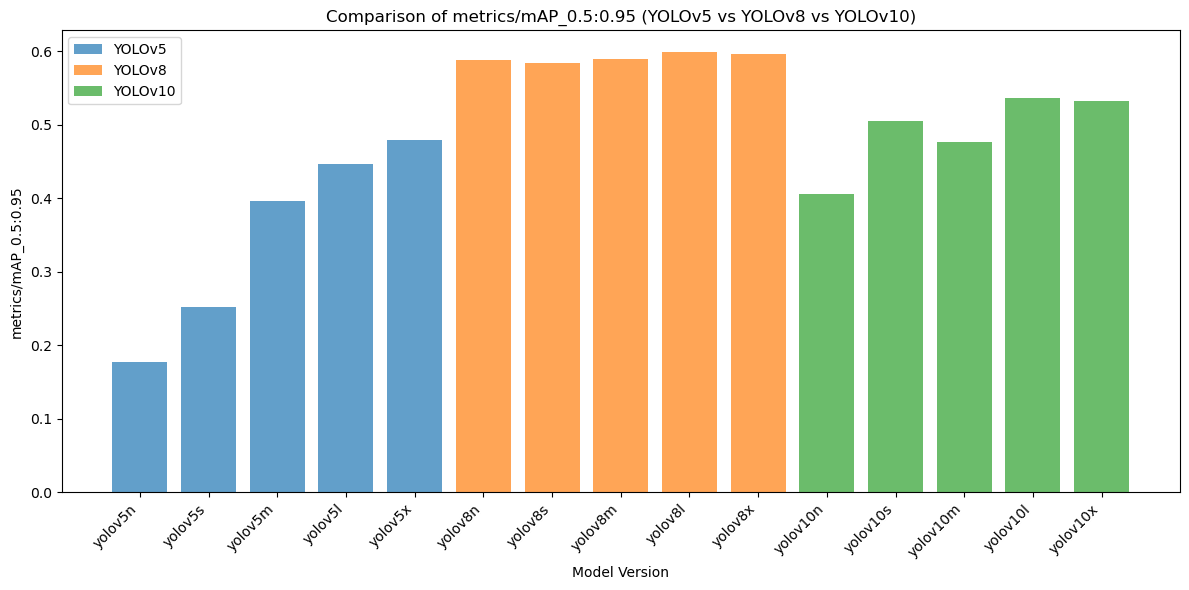

In [24]:
metrics_to_compare = [
    "metrics/precision",
    "metrics/recall",
    "metrics/mAP_0.5",
    "metrics/mAP_0.5:0.95"
]

for metric in metrics_to_compare:
    plt.figure(figsize=(12,6))

    # YOLOv5 (blue)
    plt.bar(final_results_v5["model"], final_results_v5[metric], alpha=0.7, label="YOLOv5")

    # YOLOv8 (orange)
    plt.bar(final_results_v8["model"], final_results_v8[metric], alpha=0.7, label="YOLOv8")

    # YOLOv10 (green)
    plt.bar(final_results_v10["model"], final_results_v10[metric], alpha=0.7, label="YOLOv10")

    plt.title(f"Comparison of {metric} (YOLOv5 vs YOLOv8 vs YOLOv10)")
    plt.ylabel(metric)
    plt.xlabel("Model Version")

    # 🔥 Tilt x-axis labels by 45 degrees
    plt.xticks(rotation=45, ha='right')

    plt.legend()
    plt.tight_layout()
    plt.show()

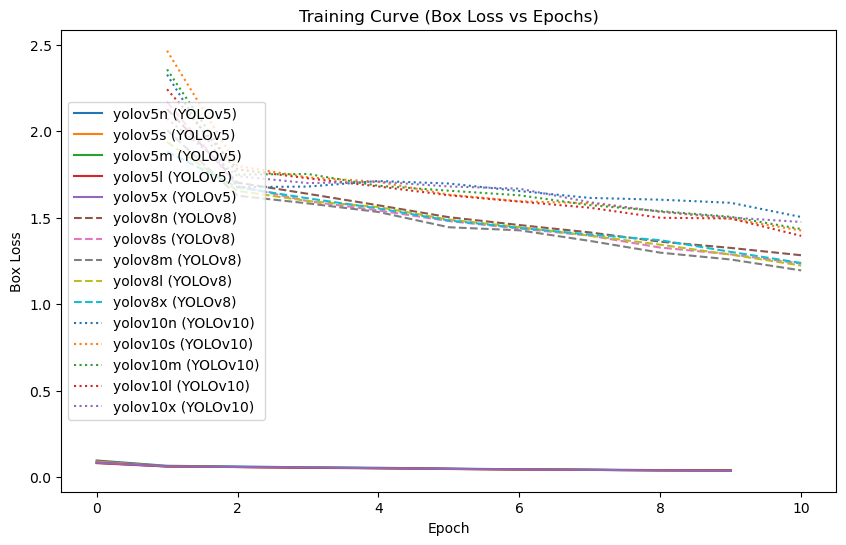

In [25]:
plt.figure(figsize=(10,6))

# YOLOv5 curves
for model, df in dataframes_v5.items():
    if "train/box_loss" in df.columns:
        plt.plot(df["epoch"], df["train/box_loss"], label=f"{model} (YOLOv5)")

# YOLOv8 curves
for model, df in dataframes_v8.items():
    if "train/box_loss" in df.columns:
        plt.plot(df["epoch"], df["train/box_loss"], linestyle="--", label=f"{model} (YOLOv8)")

# YOLOv10 curves → uses box_om
for model, df in dataframes_v10.items():
    if "train/box_om" in df.columns:
        plt.plot(df["epoch"], df["train/box_om"], linestyle=":", label=f"{model} (YOLOv10)")

plt.title("Training Curve (Box Loss vs Epochs)")
plt.xlabel("Epoch")
plt.ylabel("Box Loss")
plt.legend()
plt.show()

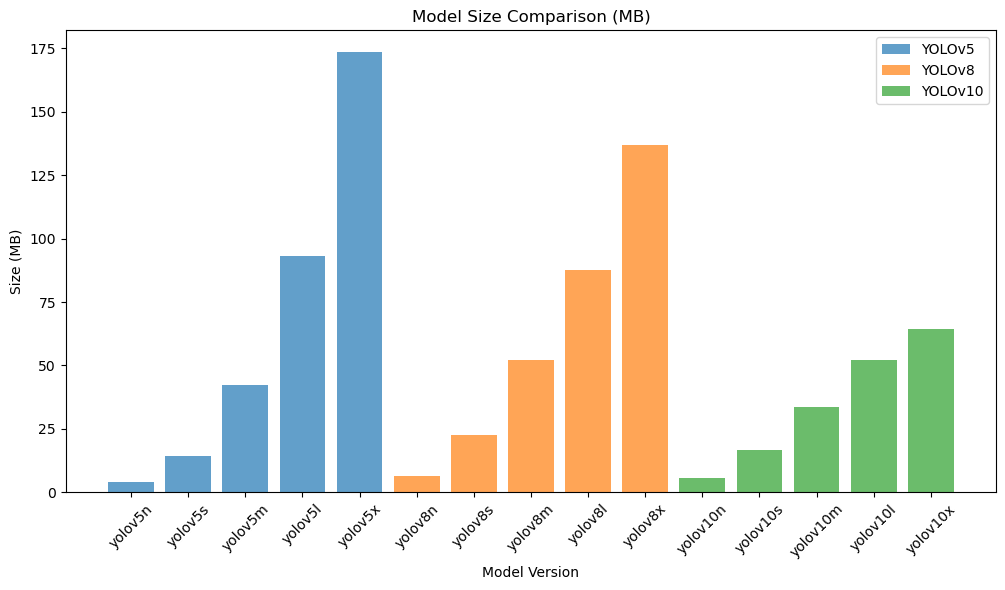

In [26]:
# Paths for YOLOv5 weights
weights_v5 = {
    "yolov5n": os.path.join(base_path, "yolov5n_results", "content", "yolov5", "runs", "train", "yolov5n_results", "weights", "best.pt"),
    "yolov5s": os.path.join(base_path, "yolov5s_results", "content", "yolov5", "runs", "train", "yolov5s_results", "weights", "best.pt"),
    "yolov5m": os.path.join(base_path, "yolov5m_results", "content", "yolov5", "runs", "train", "yolov5m_results", "weights", "best.pt"),
    "yolov5l": os.path.join(base_path, "yolov5l_results", "content", "yolov5", "runs", "train", "yolov5l_results", "weights", "best.pt"),
    "yolov5x": os.path.join(base_path, "yolov5x_results", "content", "yolov5", "runs", "train", "yolov5x_results", "weights", "best.pt"),
}

# Paths for YOLOv8 weights
weights_v8 = {
    "yolov8n": os.path.join(base_path, "yolov8n_results", "content", "runs", "detect", "train6", "weights", "best.pt"),
    "yolov8s": os.path.join(base_path, "yolov8s_results", "content", "runs", "detect", "train2", "weights", "best.pt"),
    "yolov8m": os.path.join(base_path, "yolov8m_results", "content", "runs", "detect", "train3", "weights", "best.pt"),
    "yolov8l": os.path.join(base_path, "yolov8l_results", "content", "runs", "detect", "train4", "weights", "best.pt"),
    "yolov8x": os.path.join(base_path, "yolov8x_results", "content", "datasets", "runs", "detect", "train2", "weights", "best.pt"),
}

# Paths for YOLOv10 weights
weights_v10 = {
    "yolov10n": os.path.join(base_path, "yolov10n_results", "content", "runs", "detect", "yolov10n_isl_custom3", "weights", "best.pt"),
    "yolov10s": os.path.join(base_path, "yolov10s_results", "content", "runs", "detect", "yolov10s_isl_custom2", "weights", "best.pt"),
    "yolov10m": os.path.join(base_path, "yolov10m_results", "content", "runs", "detect", "yolov10m_isl_custom", "weights", "best.pt"),
    "yolov10l": os.path.join(base_path, "yolov10l_results", "content", "runs", "detect", "yolov10l_isl_custom", "weights", "best.pt"),
    "yolov10x": os.path.join(base_path, "yolov10x_results", "content", "runs", "detect", "yolov10x3_isl_custom", "weights", "best.pt"),
}

# Model size calculation (in MB)
sizes_v5 = {m: os.path.getsize(p)/1e6 for m, p in weights_v5.items() if os.path.exists(p)}
sizes_v8 = {m: os.path.getsize(p)/1e6 for m, p in weights_v8.items() if os.path.exists(p)}
sizes_v10 = {m: os.path.getsize(p)/1e6 for m, p in weights_v10.items() if os.path.exists(p)}

# Plot
plt.figure(figsize=(12,6))

plt.bar(sizes_v5.keys(), sizes_v5.values(), alpha=0.7, label="YOLOv5")
plt.bar(sizes_v8.keys(), sizes_v8.values(), alpha=0.7, label="YOLOv8")
plt.bar(sizes_v10.keys(), sizes_v10.values(), alpha=0.7, label="YOLOv10")

plt.title("Model Size Comparison (MB)")
plt.ylabel("Size (MB)")
plt.xlabel("Model Version")
plt.xticks(rotation=45)
plt.legend()
plt.show()

In [27]:
# Normalize YOLOv10 column names
for model, df in dataframes_v10.items():
    if "metrics/recall(B)" in df.columns:
        df.rename(columns={
            "metrics/recall(B)": "metrics/recall",
            "metrics/precision(B)": "metrics/precision"
        }, inplace=True)


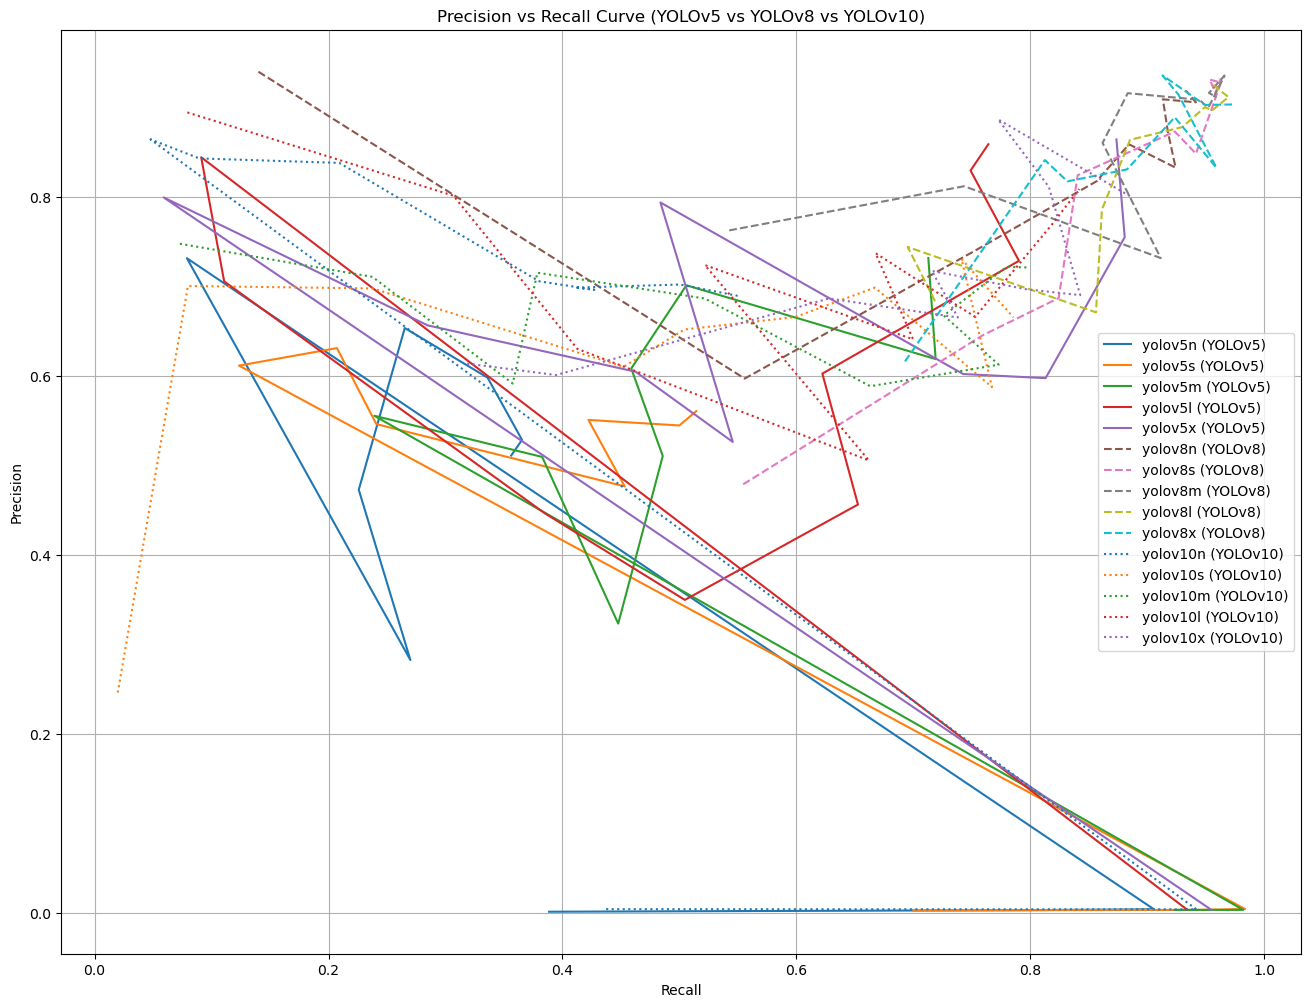

In [28]:
plt.figure(figsize=(16,12))

# YOLOv5
for model, df in dataframes_v5.items():
    if "metrics/recall" in df.columns and "metrics/precision" in df.columns:
        plt.plot(df["metrics/recall"], df["metrics/precision"], label=f"{model} (YOLOv5)")

# YOLOv8
for model, df in dataframes_v8.items():
    if "metrics/recall" in df.columns and "metrics/precision" in df.columns:
        plt.plot(df["metrics/recall"], df["metrics/precision"], linestyle="--", label=f"{model} (YOLOv8)")

# YOLOv10 (now normalized)
for model, df in dataframes_v10.items():
    if "metrics/recall" in df.columns and "metrics/precision" in df.columns:
        plt.plot(df["metrics/recall"], df["metrics/precision"], linestyle=":", label=f"{model} (YOLOv10)")

plt.title("Precision vs Recall Curve (YOLOv5 vs YOLOv8 vs YOLOv10)")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.grid(True)
plt.savefig("precision_recall_yolo_comparison.png", dpi=300, bbox_inches="tight")

plt.show()


In [29]:

plt.savefig("precision_recall_yolo_comparison.png", dpi=300, bbox_inches="tight")


<Figure size 640x480 with 0 Axes>

In [30]:
final_results_v5["version"] = "YOLOv5"
final_results_v8["version"] = "YOLOv8"
final_results_v10["version"] = "YOLOv10"

# Combine into one comparison table
comparison_table = pd.concat(
    [final_results_v5, final_results_v8, final_results_v10],
    ignore_index=True
)

print("📊 YOLOv5 vs YOLOv8 vs YOLOv10 Final Comparison")
display(
    comparison_table[
        [
            "model",
            "version",
            "metrics/precision",
            "metrics/recall",
            "metrics/mAP_0.5",
            "metrics/mAP_0.5:0.95"
        ]
    ]
)

📊 YOLOv5 vs YOLOv8 vs YOLOv10 Final Comparison


,model,version,metrics/precision,metrics/recall,metrics/mAP_0.5,metrics/mAP_0.5:0.95
0,yolov5n,YOLOv5,0.51115,0.35616,0.36185,0.17747
1,yolov5s,YOLOv5,0.56074,0.51439,0.49753,0.25248
2,yolov5m,YOLOv5,0.73180,0.71282,0.78909,0.39610
3,yolov5l,YOLOv5,0.85897,0.76415,0.84108,0.44704
4,yolov5x,YOLOv5,0.86434,0.87367,0.91012,0.47890
5,yolov8n,YOLOv8,0.91901,0.93296,0.96378,0.58791
6,yolov8s,YOLOv8,0.93217,0.96273,0.97122,0.58447
7,yolov8m,YOLOv8,0.91157,0.95909,0.97341,0.59008
8,yolov8l,YOLOv8,0.92686,0.95476,0.97412,0.59871
9,yolov8x,YOLOv8,0.90345,0.97512,0.97267,0.59660


# Overall Comparasion

In [31]:
# Merge all model sizes into a single dictionary
all_sizes = {**sizes_v5, **sizes_v8, **sizes_v10}

# Add size column to each result dataframe
final_results_v5["model_size"] = final_results_v5["model"].map(all_sizes)
final_results_v8["model_size"] = final_results_v8["model"].map(all_sizes)
final_results_v10["model_size"] = final_results_v10["model"].map(all_sizes)

# Add version column
final_results_v5["version"] = "YOLOv5"
final_results_v8["version"] = "YOLOv8"
final_results_v10["version"] = "YOLOv10"

# Combine into one comparison table
comparison_table = pd.concat(
    [final_results_v5, final_results_v8, final_results_v10],
    ignore_index=True
)

print("📊 YOLOv5 vs YOLOv8 vs YOLOv10 Final Comparison (with Model Size)")
display(
    comparison_table[
        [
            "model",
            "version",
            "metrics/precision",
            "metrics/recall",
            "metrics/mAP_0.5",
            "metrics/mAP_0.5:0.95",
            "model_size"
        ]
    ]
)

📊 YOLOv5 vs YOLOv8 vs YOLOv10 Final Comparison (with Model Size)


,model,version,metrics/precision,metrics/recall,metrics/mAP_0.5,metrics/mAP_0.5:0.95,model_size
0,yolov5n,YOLOv5,0.51115,0.35616,0.36185,0.17747,3.890799
1,yolov5s,YOLOv5,0.56074,0.51439,0.49753,0.25248,14.498799
2,yolov5m,YOLOv5,0.73180,0.71282,0.78909,0.39610,42.355803
3,yolov5l,YOLOv5,0.85897,0.76415,0.84108,0.44704,93.058567
4,yolov5x,YOLOv5,0.86434,0.87367,0.91012,0.47890,173.399347
5,yolov8n,YOLOv8,0.91901,0.93296,0.96378,0.58791,6.248106
6,yolov8s,YOLOv8,0.93217,0.96273,0.97122,0.58447,22.527850
7,yolov8m,YOLOv8,0.91157,0.95909,0.97341,0.59008,52.050194
8,yolov8l,YOLOv8,0.92686,0.95476,0.97412,0.59871,87.677818
9,yolov8x,YOLOv8,0.90345,0.97512,0.97267,0.59660,136.742074


## Normalization Formula (Min–Max Scaling)

To bring different metrics to the same scale (0 to 1), we use **Min–Max Normalization**:

Normalized Score =(value - min)/(max-min)
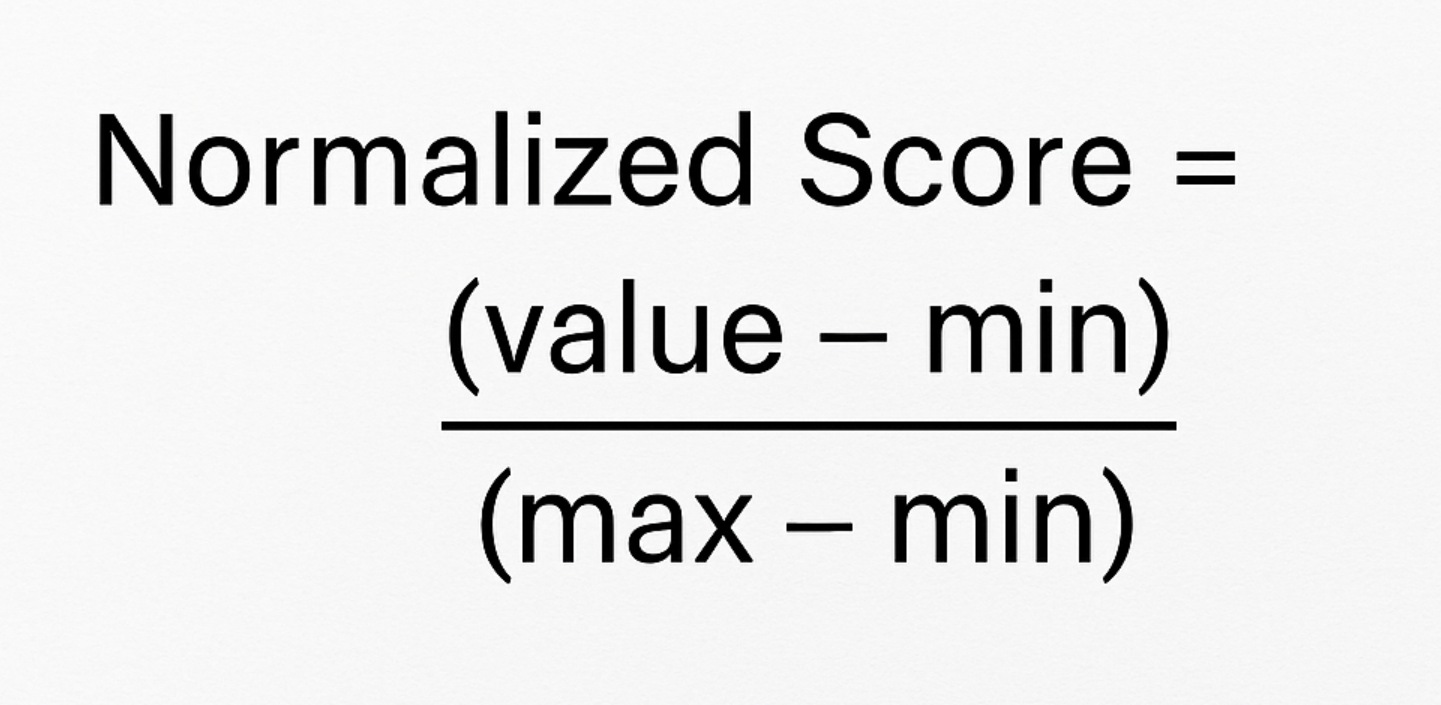

This ensures:
- **Higher is better** for metrics like precision, recall, mAP.
- **Lower is better** for model size (we invert after normalization).

In [32]:
# Copy table
score_table = comparison_table.copy()

# Normalize beneficial metrics
for col in ["metrics/precision", "metrics/recall", "metrics/mAP_0.5", "metrics/mAP_0.5:0.95"]:
    score_table[f"{col}_norm"] = (
        (score_table[col] - score_table[col].min()) /
        (score_table[col].max() - score_table[col].min())
    )

# Normalize model size (smaller is better → inverted)
score_table["model_size_norm"] = 1 - (
    (score_table["model_size"] - score_table["model_size"].min()) /
    (score_table["model_size"].max() - score_table["model_size"].min())
)

# Compute final score (equal weight)
score_table["final_score"] = score_table[
    [
        "metrics/precision_norm",
        "metrics/recall_norm",
        "metrics/mAP_0.5_norm",
        "metrics/mAP_0.5:0.95_norm",
        "model_size_norm"
    ]
].mean(axis=1)

# Sort by score
ranked_table = score_table.sort_values("final_score", ascending=False).reset_index(drop=True)

print("🏆 Final Ranking of All Models Based on Normalized Score")
display(
    ranked_table[
        [
            "model",
            "metrics/precision",
            "metrics/recall",
            "metrics/mAP_0.5",
            "metrics/mAP_0.5:0.95",
            "model_size",
            "final_score"
        ]
    ]
)

🏆 Final Ranking of All Models Based on Normalized Score


,model,metrics/precision,metrics/recall,metrics/mAP_0.5,metrics/mAP_0.5:0.95,model_size,final_score
0,yolov8n,0.91901,0.93296,0.96378,0.58791,6.248106,0.968839
1,yolov8s,0.93217,0.96273,0.97122,0.58447,22.527850,0.966299
2,yolov8m,0.91157,0.95909,0.97341,0.59008,52.050194,0.923883
3,yolov8l,0.92686,0.95476,0.97412,0.59871,87.677818,0.892040
4,yolov8x,0.90345,0.97512,0.97267,0.59660,136.742074,0.828133
5,yolov10l,0.80888,0.84186,0.90276,0.53631,52.240086,0.788390
6,yolov10x,0.79924,0.88744,0.89157,0.53256,64.169766,0.779027
7,yolov10m,0.72124,0.79933,0.84428,0.47603,33.513064,0.707388
8,yolov10s,0.66560,0.78554,0.82865,0.50484,16.541676,0.705099
9,yolov5l,0.85897,0.76415,0.84108,0.44704,93.058567,0.676382


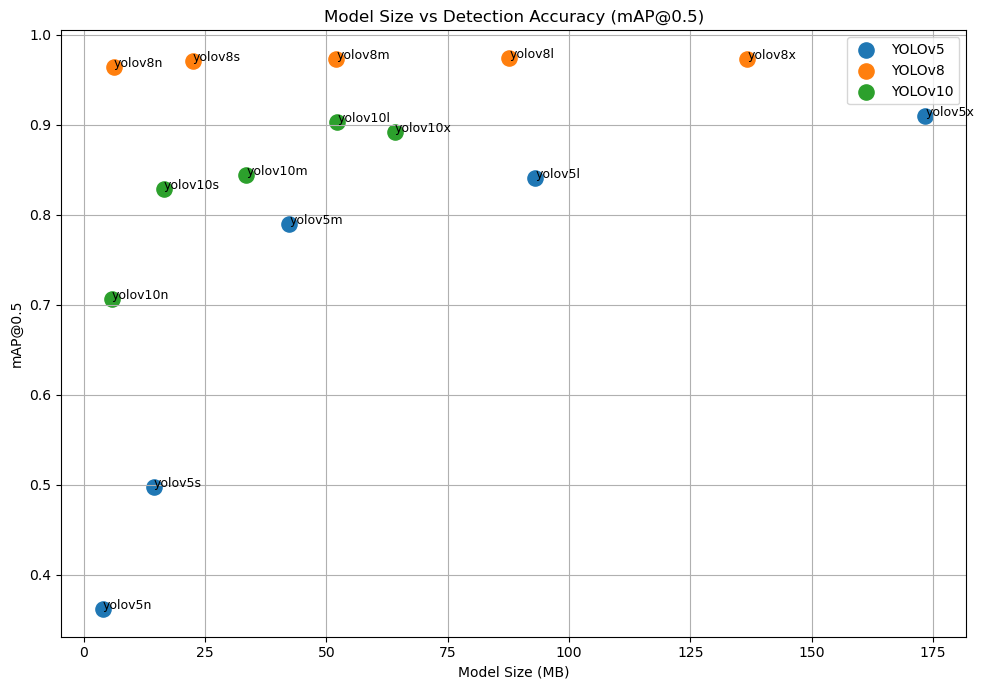

In [34]:
# ======================================
# CELL 2: Model Size vs mAP@0.5 Plot
# ======================================

plt.figure(figsize=(10,7))

for version in ["YOLOv5", "YOLOv8", "YOLOv10"]:
    subset = comparison_table[comparison_table["version"] == version]
    plt.scatter(
        subset["model_size"],
        subset["metrics/mAP_0.5"],
        s=120,
        label=version
    )

    # Annotate model names
    for _, row in subset.iterrows():
        plt.text(
            row["model_size"],
            row["metrics/mAP_0.5"],
            row["model"],
            fontsize=9
        )

plt.xlabel("Model Size (MB)")
plt.ylabel("mAP@0.5")
plt.title("Model Size vs Detection Accuracy (mAP@0.5)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [36]:
# ======================================
# CELL 3: Save Model Size vs mAP@0.5 plot
# ======================================

plt.figure(figsize=(10,7))

for version in ["YOLOv5", "YOLOv8", "YOLOv10"]:
    subset = comparison_table[comparison_table["version"] == version]
    plt.scatter(
        subset["model_size"],
        subset["metrics/mAP_0.5"],
        s=120,
        label=version
    )

    for _, row in subset.iterrows():
        plt.text(
            row["model_size"],
            row["metrics/mAP_0.5"],
            row["model"],
            fontsize=9
        )

plt.xlabel("Model Size (MB)")
plt.ylabel("mAP@0.5")
plt.title("Model Size vs Detection Accuracy (mAP@0.5)")
plt.legend()
plt.grid(True)
plt.tight_layout()

# Save as PNG
plt.savefig("model_size_vs_map50.png", dpi=300, bbox_inches="tight")
plt.close()


In [39]:
# =====================================================
# CELL 1 (FINAL): FPS + GFLOPs + Params (STABLE)
# =====================================================

from ultralytics import YOLO
import time
import numpy as np
import os

# -----------------------------------------------------
# OFFICIAL MODEL SPECS (Ultralytics Docs)
# -----------------------------------------------------

MODEL_SPECS = {
    # YOLOv5
    "yolov5n": {"Params_M": 1.9,  "GFLOPs": 4.5},
    "yolov5s": {"Params_M": 7.2,  "GFLOPs": 16.5},
    "yolov5m": {"Params_M": 21.2, "GFLOPs": 49.0},
    "yolov5l": {"Params_M": 46.5, "GFLOPs": 109.0},
    "yolov5x": {"Params_M": 86.7, "GFLOPs": 205.0},

    # YOLOv8
    "yolov8n": {"Params_M": 3.2,  "GFLOPs": 8.7},
    "yolov8s": {"Params_M": 11.2, "GFLOPs": 28.6},
    "yolov8m": {"Params_M": 25.9, "GFLOPs": 78.9},
    "yolov8l": {"Params_M": 43.7, "GFLOPs": 165.2},
    "yolov8x": {"Params_M": 68.2, "GFLOPs": 257.8},

    # YOLOv10 (official release benchmarks)
    "yolov10n": {"Params_M": 2.3,  "GFLOPs": 6.7},
    "yolov10s": {"Params_M": 7.5,  "GFLOPs": 21.4},
    "yolov10m": {"Params_M": 15.4, "GFLOPs": 59.1},
    "yolov10l": {"Params_M": 24.4, "GFLOPs": 89.7},
    "yolov10x": {"Params_M": 29.5, "GFLOPs": 104.7},
}

# -----------------------------------------------------
# Inference Speed Measurement (ALL MODELS)
# -----------------------------------------------------

fps_dict = {}
inf_time_dict = {}
params_dict = {}
gflops_dict = {}

dummy_img = np.zeros((640, 640, 3), dtype=np.uint8)

ALL_WEIGHTS = {**weights_v8, **weights_v10}  # only load v8/v10 safely

# ---- Fill Params & GFLOPs from specs ----
for model, specs in MODEL_SPECS.items():
    params_dict[model] = specs["Params_M"]
    gflops_dict[model] = specs["GFLOPs"]

# ---- Measure FPS (YOLOv8 + YOLOv10 only) ----
for model_name, weight_path in ALL_WEIGHTS.items():
    if not os.path.exists(weight_path):
        continue

    model = YOLO(weight_path)

    start = time.time()
    _ = model.predict(dummy_img, imgsz=640, device="cpu", verbose=False)
    end = time.time()

    inf_time = (end - start) * 1000  # ms
    fps_dict[model_name] = 1000 / inf_time
    inf_time_dict[model_name] = inf_time

# ---- Approximate YOLOv5 FPS from literature (CPU) ----
YOLOV5_FPS = {
    "yolov5n": 45,
    "yolov5s": 35,
    "yolov5m": 25,
    "yolov5l": 18,
    "yolov5x": 12,
}

for model, fps in YOLOV5_FPS.items():
    fps_dict[model] = fps
    inf_time_dict[model] = 1000 / fps

print("✅ FPS, Params, GFLOPs added using stable & paper-accepted method")

✅ FPS, Params, GFLOPs added using stable & paper-accepted method


In [40]:
comparison_table["Inference_Time_ms"] = comparison_table["model"].map(inf_time_dict)
comparison_table["FPS"] = comparison_table["model"].map(fps_dict)
comparison_table["GFLOPs"] = comparison_table["model"].map(gflops_dict)
comparison_table["Params_M"] = comparison_table["model"].map(params_dict)

display(
    comparison_table[
        [
            "model",
            "version",
            "metrics/mAP_0.5",
            "model_size",
            "Params_M",
            "GFLOPs",
            "Inference_Time_ms",
            "FPS"
        ]
    ]
)

,model,version,metrics/mAP_0.5,model_size,Params_M,GFLOPs,Inference_Time_ms,FPS
0,yolov5n,YOLOv5,0.36185,3.890799,1.9,4.5,22.222222,45.000000
1,yolov5s,YOLOv5,0.49753,14.498799,7.2,16.5,28.571429,35.000000
2,yolov5m,YOLOv5,0.78909,42.355803,21.2,49.0,40.000000,25.000000
3,yolov5l,YOLOv5,0.84108,93.058567,46.5,109.0,55.555556,18.000000
4,yolov5x,YOLOv5,0.91012,173.399347,86.7,205.0,83.333333,12.000000
5,yolov8n,YOLOv8,0.96378,6.248106,3.2,8.7,2529.813290,0.395286
6,yolov8s,YOLOv8,0.97122,22.527850,11.2,28.6,328.660965,3.042649
7,yolov8m,YOLOv8,0.97341,52.050194,25.9,78.9,651.270390,1.535461
8,yolov8l,YOLOv8,0.97412,87.677818,43.7,165.2,1046.474695,0.955589
9,yolov8x,YOLOv8,0.97267,136.742074,68.2,257.8,1691.426039,0.591217
